In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ucf101-action-recognition/val.csv
/kaggle/input/ucf101-action-recognition/train.csv
/kaggle/input/ucf101-action-recognition/test.csv
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g11_c01.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g19_c03.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g16_c05.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g14_c02.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g23_c03.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g03_c01.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g17_c04.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g20_c05.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g14_c03.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g19_c01.avi
/kaggle/input/ucf101-action-recognition/val/HorseRace/v_HorseRace_g16_c04

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt 
import os 
from glob import glob 

#getting the dataset
dataset_path = "/kaggle/input/ucf101-action-recognition/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi"
print()

if os.path.exists(dataset_path):
    print("File does exist here and the path is indeed correct here")
else:
    print("File is not found here")

#glob can be thought as regex steroids 
'''
Symbol 	Name	Description
*	Asterisk	Matches any sequence of characters (including none) within a single path segment.
?	Question Mark	Matches exactly one single character.
[]	Character Range	Matches any single character specified within the brackets (e.g., [abc], [0-9]).
**	Double Asterisk	Matches any files and zero or more directories/subdirectories when recursive=True is set as an argument to the function
'''
videoi = "/kaggle/input/ucf101-action-recognition/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi"

cap = cv.VideoCapture(videoi)
fps = cap.get(cv.CAP_PROP_FPS)
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))

print(cap, '\n', fps, '\n', frame_count, '\n', width, '\n', height)
frames = []
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret :
        break
    frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB) #CONVERTING THE STUFF INTO THE REQUIRED INPUT THE NEXT FUNCTION NEEDS 
    
    #print(frame_rgb) #4D or 3D arrays and why and why not flatten them like the others to process from 
    #print(frame_rgb.shape)
    
    frames.append(frame_rgb)
    frame_idx = frame_idx + 1

cap.release()

plt.tight_layout()
plt.savefig('video_frames_timeline.png', dpi = 150, bbox_inches = 'tight')
plt.show()


File does exist here and the path is indeed correct here
< cv2.VideoCapture 0x7cb1a158b750> 
 25.0 
 164 
 320 
 240


<Figure size 640x480 with 0 Axes>

In [21]:
frames = np.array(frames)
print(f"\nExtracted frames shape: {frames.shape}")
print(f"  Interpretation: ({frames.shape[0]} frames, {frames.shape[1]}H, {frames.shape[2]}W, {frames.shape[3]} channels)")
print(f"  Pixel value range: {frames.min()} to {frames.max()}")
print(f"  Data type: {frames.dtype}")
print(f"  Memory size: {frames.nbytes / 1e6:.1f} MB")



Extracted frames shape: (164, 240, 320, 3)
  Interpretation: (164 frames, 240H, 320W, 3 channels)
  Pixel value range: 0 to 255
  Data type: uint8
  Memory size: 37.8 MB


Text(0.5, 0.98, 'Video Frames at different time points')

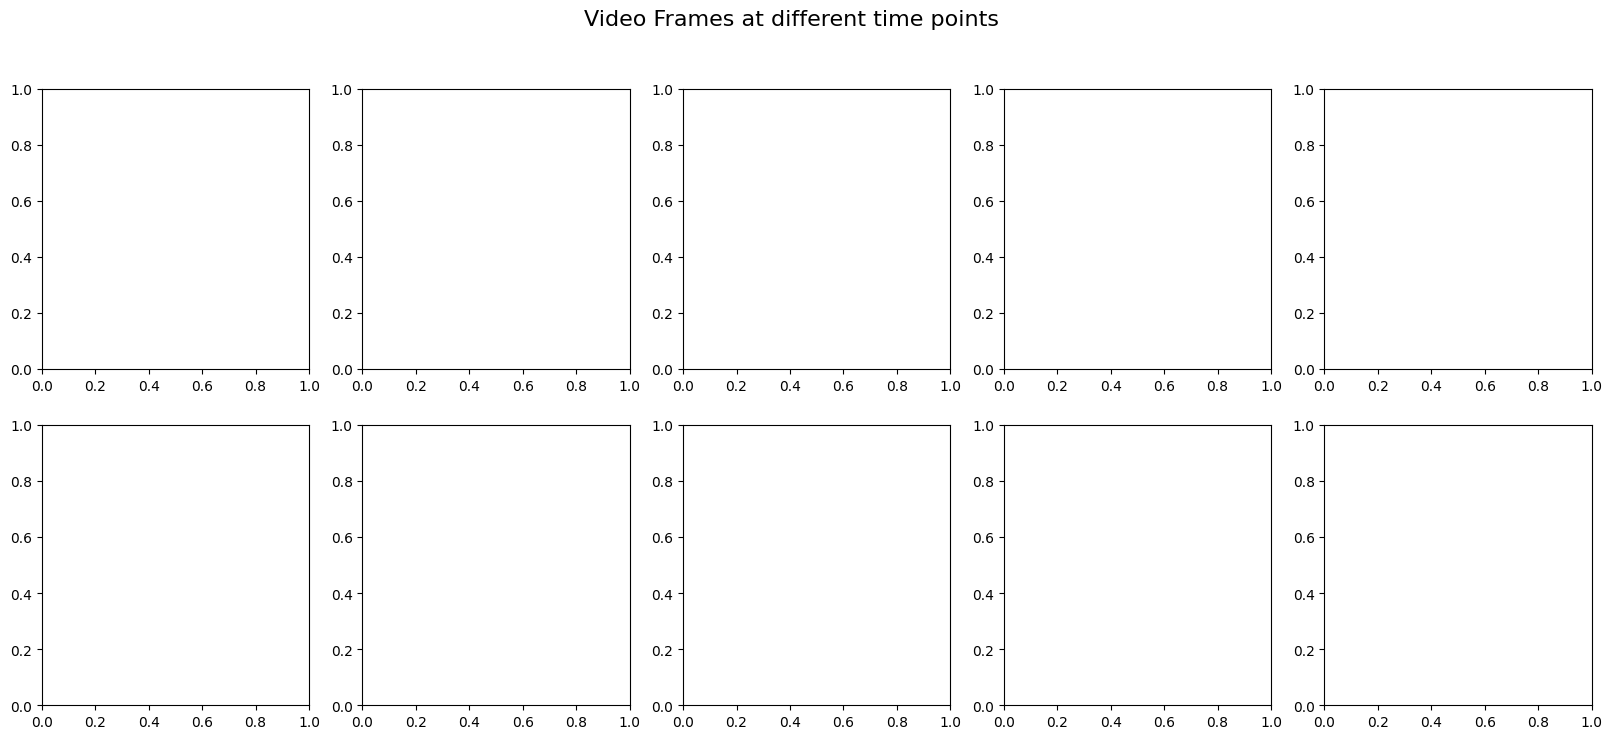

In [23]:
for i, ax in enumerate(axes.flat):
    frame_position = int((i/10) * len(frames))
    ax.imshow(frames[frame_position])
    ax.set_title(f'Name {frame_position}/{len(frames)}({i*10}%)')
    ax.axis('off')



File does exist here and the path is indeed correct here
< cv2.VideoCapture 0x7cb1b4350a70> 
 25.0 
 164 
 320 
 240

Extracted frames shape: (1, 240, 320, 3)
 Interpretation: (1 frames, 240H, 320W, 3 channels)
 Pixel value range: 0 to 255
 Data type: uint8
 Memory size: 0.2 MB


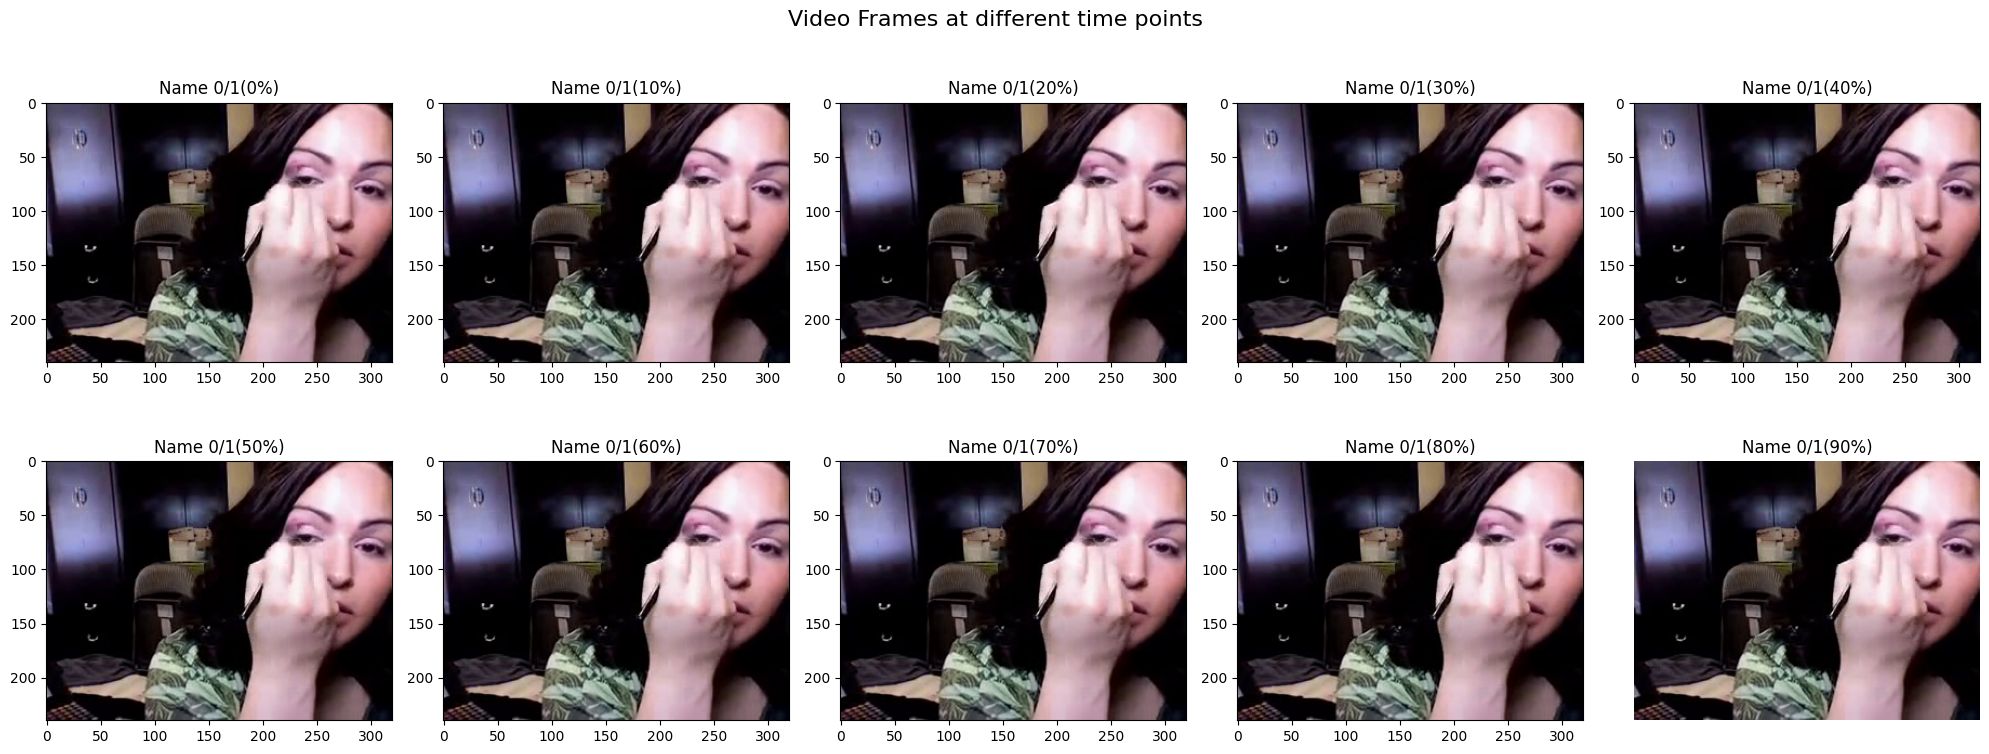

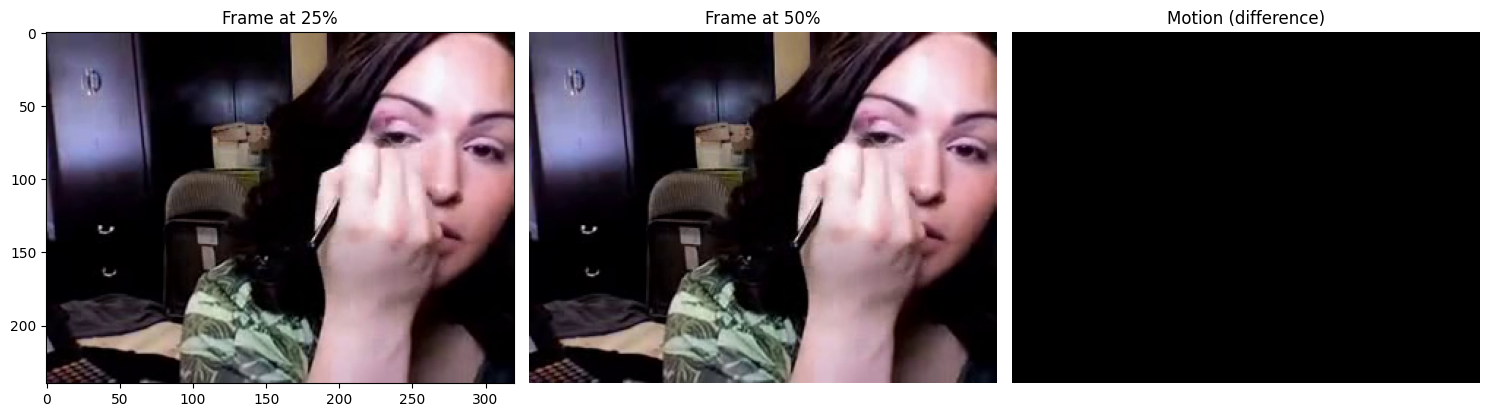


★1 UNDERSTANDING CHECK:
1. Video = sequence of images (frames) over time ✓
2. Each frame = 3D array (height, width, RGB channels) ✓
3. Video = 4D array (time, height, width, channels) ✓
4. Motion = change between frames ✓
5. Temporal patterns = motion + sequence ✓


In [33]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

#getting the dataset
dataset_path = "/kaggle/input/ucf101-action-recognition/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi"
print()

if os.path.exists(dataset_path):
    print("File does exist here and the path is indeed correct here")
else:
    print("File is not found here")

#glob can be thought as regex steroids
'''
Symbol Name Description
* Asterisk Matches any sequence of characters (including none) within a single path segment.
? Question Mark Matches exactly one single character.
[] Character Range Matches any single character specified within the brackets (e.g., [abc], [0-9]).
** Double Asterisk Matches any files and zero or more directories/subdirectories when recursive=True is set as an argument to the function
'''
videoi = "/kaggle/input/ucf101-action-recognition/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi"

cap = cv.VideoCapture(videoi)
fps = cap.get(cv.CAP_PROP_FPS)
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))

print(cap, '\n', fps, '\n', frame_count, '\n', width, '\n', height)
frames = []
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret :
        break
    frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB) #CONVERTING THE STUFF INTO THE REQUIRED INPUT THE NEXT FUNCTION NEEDS

#print(frame_rgb) #4D or 3D arrays and why and why not flatten them like the others to process from
#print(frame_rgb.shape)
frames.append(frame_rgb)
frame_idx = frame_idx + 1

cap.release()
frames = np.array(frames)
print(f"\nExtracted frames shape: {frames.shape}")
print(f" Interpretation: ({frames.shape[0]} frames, {frames.shape[1]}H, {frames.shape[2]}W, {frames.shape[3]} channels)")
print(f" Pixel value range: {frames.min()} to {frames.max()}")
print(f" Data type: {frames.dtype}")
print(f" Memory size: {frames.nbytes / 1e6:.1f} MB")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Video Frames at different time points', fontsize=16)

for i, ax in enumerate(axes.flat):
    frame_position = int((i/10) * len(frames))
    ax.imshow(frames[frame_position])
    ax.set_title(f'Name {frame_position}/{len(frames)}({i*10}%)')
ax.axis('off')

plt.tight_layout()
plt.savefig('video_frames_timeline.png', dpi = 150, bbox_inches = 'tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize = (15, 5))
frame_25 = frames[len(frames)//4]
frame_50 = frames[len(frames)//2]
motion = np.abs(frame_50.astype(int) - frame_25.astype(int))

axes[0].imshow(frame_25)
axes[0].set_title('Frame at 25%')


axes[1].imshow(frame_50)
axes[1].set_title("Frame at 50%")
axes[1].axis('off')

axes[2].imshow(motion)
axes[2].set_title('Motion (difference)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('motion_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n★1 UNDERSTANDING CHECK:")
print("1. Video = sequence of images (frames) over time ✓")
print("2. Each frame = 3D array (height, width, RGB channels) ✓")
print("3. Video = 4D array (time, height, width, channels) ✓")
print("4. Motion = change between frames ✓")
print("5. Temporal patterns = motion + sequence ✓")


In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.model_selection import train_test_split
#getting the dataset
dataset_path = "/kaggle/input/ucf101-action-recognition/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi"
print()
base_path = "/kaggle/input/ucf101-action-recognition/train"

if os.path.exists(dataset_path):
    print("File does exist here and the path is indeed correct here \n")
else:
    print("File is not found here")

classes = sorted(os.listdir(base_path))
print(classes[:15], "\n") #prints the last 15 objects of a class
print("Total classes :", len(classes))


def load_video(path, num_frames=32, img_size = (112, 112)):
    cap = cv2.VideoCapture(path)
    frames = []
    #reading the frames 
    while True:
        ret,  frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, img_size)
        #append the resized and the fitted image in here
        frames.append(frame)
    #release the video input here
    cap.release()
    if len(frames) == 0:
        print("corrupted video try again")
        return None
    frames = np.array(frames) #wonedering what this actually does !
    L = len(frames) #wont it give the entire all video length 


    #temporal sampling to extract the required features here.
    if L == num_frames:
        sampled = frames
    elif L > num_frames:
        idxs = np.linspace(0, L-1, num_frames).astype(int)
        sampled = frames[idxs]
    else:
        pad_count = num_frames - L 
        pad = np.repeat(frames[-1][None, ...], pad_count, axis = 0)
        sampled = np.concatenate([frames, pad], axis=0)
    
    sampled = sampled.astype("float32")/255.0
    return sampled

videos_per_class = 20
num_frames = 32
img_size = (112, 112)
selected_classes = ["Basketball", "WritingOnBoard", "ApplyEyeMakeup"]

X_list = []
y_list = []
class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}

for cls in selected_classes:
    cls_dir = os.path.join(base_path, cls)
    all_videos = sorted(glob(os.path.join(cls_dir, "*.avi")))
    print(f"{cls}: found {len(all_videos)} videos.")
    
    for path in all_videos[:videos_per_class]:
        tensor = load_video(path, num_frames=num_frames, img_size=img_size)
        if tensor is None:
            print("  Skipping corrupt:", path)
            continue
        X_list.append(tensor)
        y_list.append(class_to_idx[cls])


X = np.stack(X_list, axis=0)
y = np.array(y_list)

print("\n★2 DATA READY")
print("X shape:", X.shape)  # expected: (N, 32, 112, 112, 3)
print("y shape:", y.shape)  # expected: (N,)
print("Classes mapping:", class_to_idx)
print("Pixel range:", X.min(), "to", X.max())
print("Approx memory (X):", X.nbytes / 1e6, "MB")


X_train, X_val, y_train, y_val = train_test_split(
    X,y, test_size = 0.2, random_state = 42, stratify=y
)

print("train", X_train.shape, y_train.shape)
print("val", X_val.shape, y_val.shape)


File does exist here and the path is indeed correct here 

['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress', 'Biking', 'Billiards', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats'] 

Total classes : 101
Basketball: found 198 videos.
WritingOnBoard: found 114 videos.
ApplyEyeMakeup: found 108 videos.

★2 DATA READY
X shape: (60, 32, 112, 112, 3)
y shape: (60,)
Classes mapping: {'Basketball': 0, 'WritingOnBoard': 1, 'ApplyEyeMakeup': 2}
Pixel range: 0.0 to 1.0
Approx memory (X): 289.01376 MB
train (48, 32, 112, 112, 3) (48,)
val (12, 32, 112, 112, 3) (12,)


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.model_selection import train_test_split


dataset_path = "/kaggle/input/ucf101-action-recognition/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi"
print()
base_path = "/kaggle/input/ucf101-action-recognition/train"

if os.path.exists(dataset_path):
    print("The dataset path is valid please proceed forward \n")
else:
    print("The dataset path is not valid/improperly configured please mind editing the paths")

classes = sorted(os.listdir(base_path))
print()
print(classes[:15], "\n")
print("Total classes are :", len(classes))

def load_video(path, mum_frames=32, img_size=(112, 112)):
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv.resize(frame, img_size) #resizing for the network that is needed 
        frame = frames.append(frame)
    cap.release()
    #error handling
    if (len(frames) == 0):
        print("The file is corrupted try some other sources/videos")
        return None
    frames = np.array(frames)

    L = len(frames)
    if L == num_frames:
        sampled = frames
    elif L > num_frames:
        intervalled = np.linspace(0, L-1, num_frames).astype(int) #from the total of fremes pick 32 evenly seperated frames 
        sampled = frames[intervalled]
    else:
        pad_count = num_frames - L 
        pad = np.repeat(frames[-1][None, ...], pad_count, axis = 0)
        sampled = np.concatenate([frames, pad], axis=0)

    sampled = sampled.astype("float32")/255.
    return sampled

videos_per_class = 20
num_frames = 32
img_size = (112, 112)
selected_classes = ["Basketball", "WritingOnBoard", "ApplyEyeMakeup"]

X_list = []
y_list = []

class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}

for cls in selected_classes:
    cls_dir = os.path.join(base_path, cls)
    all_videos = sorted(glob(os.path.join(cls_dir, "*,avi")))
    print(f"{cls}: found {len(all_videos)} videos.")

    for path in all_videos[:videos_per_class]:
        tensor = load_video(path, num_frame=num_frames, img_size=img_size)
        if tensor is None:
            print("Skipping corrupt paths", paths)
            continue
        X_list.append(tensor)
        y_list.append(class_to_idx[cls])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

print("train", X_train.shape, y_train.shape)
print("val", X_val.shape, y_val.shape)




The dataset path is valid please proceed forward 


['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress', 'Biking', 'Billiards', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats'] 

Total classes are : 101
Basketball: found 0 videos.
WritingOnBoard: found 0 videos.
ApplyEyeMakeup: found 0 videos.


NameError: name 'X' is not defined

2025-12-24 16:49:47.443784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766594987.730535      54 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766594987.821207      54 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766594988.533717      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766594988.533797      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766594988.533802      54 computation_placer.cc:177] computation placer alr


File does exist here and the path is indeed correct here 

['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress', 'Biking', 'Billiards', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats'] 

Total classes : 101
Basketball: found 198 videos.
WritingOnBoard: found 114 videos.
ApplyEyeMakeup: found 108 videos.

★2 DATA READY
X shape: (300, 32, 112, 112, 3)
y shape: (300,)
Classes mapping: {'Basketball': 0, 'WritingOnBoard': 1, 'ApplyEyeMakeup': 2}
Pixel range: 0.0 to 1.0
Approx memory (X): 1445.0688 MB
train (240, 32, 112, 112, 3) (240,)
val (60, 32, 112, 112, 3) (60,)
   Original X_train: (240, 32, 112, 112, 3)
   First frame only: (240, 112, 112, 3)
   Discarded 31 frames per video!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-24 16:50:25.154454: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.4257 - loss: 1.0697 - val_accuracy: 0.7000 - val_loss: 0.7463
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.8193 - loss: 0.5204 - val_accuracy: 0.8000 - val_loss: 0.3755
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.8987 - loss: 0.3232 - val_accuracy: 0.8833 - val_loss: 0.3299
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.9065 - loss: 0.2666 - val_accuracy: 0.9667 - val_loss: 0.1063
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.9699 - loss: 0.0878 - val_accuracy: 0.9667 - val_loss: 0.1186
Restoring model weights from the end of the best epoch: 4.


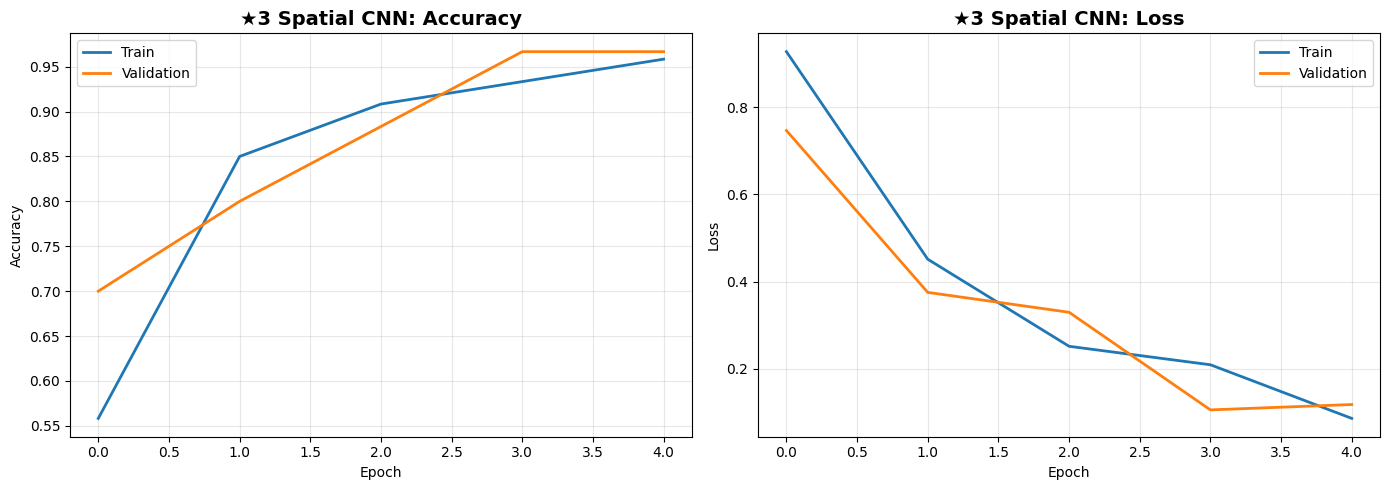

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

#getting the dataset
dataset_path = "/kaggle/input/ucf101-action-recognition/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi"
print()
base_path = "/kaggle/input/ucf101-action-recognition/train"

videos_per_class = 100
num_frames = 32
img_size = (112, 112)
selected_classes = ["Basketball", "WritingOnBoard", "ApplyEyeMakeup"]


if os.path.exists(dataset_path):
    print("File does exist here and the path is indeed correct here \n")
else:
    print("File is not found here")

classes = sorted(os.listdir(base_path))
print(classes[:15], "\n") #prints the last 15 objects of a class
print("Total classes :", len(classes))


def load_video(path, num_frames=32, img_size = (112, 112)):
    cap = cv2.VideoCapture(path)
    frames = []
    #reading the frames 
    while True:
        ret,  frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, img_size)
        #append the resized and the fitted image in here
        frames.append(frame)
    #release the video input here
    cap.release()
    if len(frames) == 0:
        print("corrupted video try again")
        return None
    frames = np.array(frames) #wonedering what this actually does !
    L = len(frames) #wont it give the entire all video length 


    #temporal sampling to extract the required features here.
    if L == num_frames:
        sampled = frames
    elif L > num_frames:
        idxs = np.linspace(0, L-1, num_frames).astype(int)
        sampled = frames[idxs]
    else:
        pad_count = num_frames - L 
        pad = np.repeat(frames[-1][None, ...], pad_count, axis = 0)
        sampled = np.concatenate([frames, pad], axis=0)
    
    sampled = sampled.astype("float32")/255.0
    return sampled


X_list = []
y_list = []
class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}

for cls in selected_classes:
    cls_dir = os.path.join(base_path, cls)
    all_videos = sorted(glob(os.path.join(cls_dir, "*.avi")))
    print(f"{cls}: found {len(all_videos)} videos.")
    
    for path in all_videos[:videos_per_class]:
        tensor = load_video(path, num_frames=num_frames, img_size=img_size)
        if tensor is None:
            print("  Skipping corrupt:", path)
            continue
        X_list.append(tensor)
        y_list.append(class_to_idx[cls])


X = np.stack(X_list, axis=0)
y = np.array(y_list)

print("\n★2 DATA READY")
print("X shape:", X.shape)  # expected: (N, 32, 112, 112, 3)
print("y shape:", y.shape)  # expected: (N,)
print("Classes mapping:", class_to_idx)
print("Pixel range:", X.min(), "to", X.max())
print("Approx memory (X):", X.nbytes / 1e6, "MB")


X_train, X_val, y_train, y_val = train_test_split(
    X,y, test_size = 0.2, random_state = 42, stratify=y
)

print("train", X_train.shape, y_train.shape)
print("val", X_val.shape, y_val.shape)

X_train_first_frame = X_train[:, 0, :, :, :]
X_val_first_frame = X_val[:, 0, :, :, :]

print(f"   Original X_train: {X_train.shape}")
print(f"   First frame only: {X_train_first_frame.shape}")
print(f"   Discarded {X_train.shape[1]-1} frames per video!")

model_spatial = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', 
           input_shape=(112, 112, 3), name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),  # 112→56
    
    # Block 2: Extract mid-level features (shapes, patterns)
    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),  # 56→28
    
    # Block 3: Extract high-level features (objects)
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
    MaxPooling2D((2, 2), name='pool3'),  # 28→14
    
    # Classification layers
    Flatten(name='flatten'),
    Dense(256, activation='relu', name='dense1'),
    Dropout(0.5, name='dropout'),
    Dense(3, activation='softmax', name='output')  # 3 classes
], name='Spatial_CNN_Baseline')

#compiling the model
model_spatial.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss='sparse_categorical_crossentropy',  # For integer labels (0,1,2)
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model_spatial.fit(
    X_train_first_frame, y_train,
    validation_data=(X_val_first_frame, y_val),
    epochs=5,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label = 'Train', linewidth = 2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('★3 Spatial CNN: Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('★3 Spatial CNN: Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('star3_spatial_cnn_results.png', dpi=150, bbox_inches='tight')
plt.show()



The file exists and the path is valid!
['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress', 'Biking', 'Billiards', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats'] 

Total classes are  101 

Basketball: found 198 videos.
WritingOnBoard: found 114 videos.
ApplyEyeMakeup: found 108 videos.
Flattened (None, 802816)


Model: "TimeDistributed_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 32, 112, 112,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv1 (TimeDistributed)      │ (None, 32, 112, 112,   │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_pool1 (TimeDistributed)      │ (None, 32, 56, 56, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv2 (TimeDistributed)      │ (None, 32, 56, 56, 64) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_pool2 (TimeDistributed)      │ (None, 32, 28, 28, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv3 (TimeDistributed)      │ (None, 32, 28, 28,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_pool3 (TimeDistributed)      │ (None, 32, 14, 14,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_flatten (TimeDistributed)    │ (None, 32, 25088)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_time (Flatten)          │ (None, 802816)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │   205,521,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,615,171 (784.36 MB)

 Trainable params: 205,615,171 (784.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 458s 8s/step - accuracy: 0.5147 - loss: 7.2249 - val_accuracy: 0.4667 - val_loss: 1.3990
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 448s 7s/step - accuracy: 0.8176 - loss: 0.5000 - val_accuracy: 0.8167 - val_loss: 0.5788
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 439s 7s/step - accuracy: 0.8964 - loss: 0.5150 - val_accuracy: 0.9167 - val_loss: 0.2402
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 442s 7s/step - accuracy: 0.9658 - loss: 0.1486 - val_accuracy: 0.9000 - val_loss: 0.1595
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 447s 7s/step - accuracy: 0.9786 - loss: 0.0479 - val_accuracy: 0.9667 - val_loss: 0.1252
Restoring model weights from the end of the best epoch: 5.


/tmp/ipykernel_55/209429986.py:298: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/209429986.py:299: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('star4_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


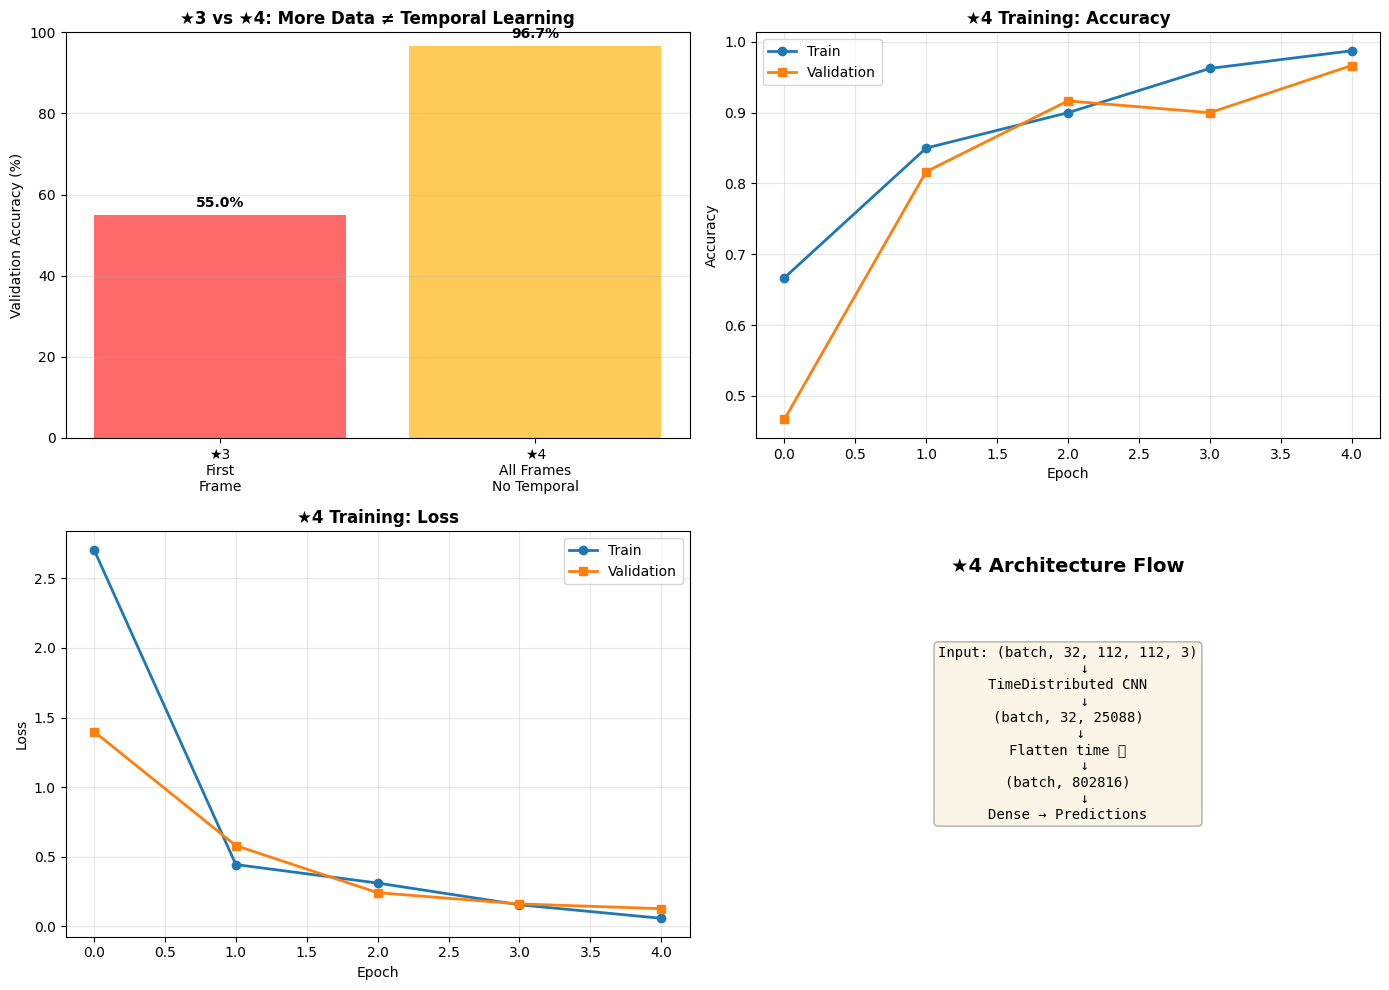

★4 COMPLETE - KEY LEARNINGS
✓ Processed all 32 frames
✓ TimeDistributed = same CNN on each frame
✓ Slight improvement from more data
❌ NO temporal sequence learning
❌ Frame order doesn't matter

💡 Next: ★5 adds LSTM for temporal patterns


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    TimeDistributed, Input, LSTM, Bidirectional
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time
import pickle

dataset_path = "/kaggle/input/ucf101-action-recognition/train/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi"
print()
base_path = "/kaggle/input/ucf101-action-recognition/train"

if os.path.exists(dataset_path):
    print("The file exists and the path is valid!")
else:
    print("The file cannot be found here")

classes = sorted(os.listdir(base_path))
print(classes[:15], "\n")
print("Total classes are ", len(classes), "\n")

# ADD THESE MISSING VARIABLES
videos_per_class = 100
num_frames = 32
img_size = (112, 112)
selected_classes = ["Basketball", "WritingOnBoard", "ApplyEyeMakeup"]

# Loading the video
def load_video(path, num_frames=32, img_size=(112, 112)):
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break 
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, img_size)
        frames.append(frame)

    cap.release()
    if len(frames) == 0:
        print("corrupted Video try again")
        return None
    frames = np.array(frames)

    L = len(frames)
    if L == num_frames:
        sampled = frames
    elif L > num_frames:
        idxs = np.linspace(0, L-1, num_frames).astype(int)
        sampled = frames[idxs]
    else:
        pad_count = num_frames - L 
        pad = np.repeat(frames[-1][None, ...], pad_count, axis=0)
        sampled = np.concatenate([frames, pad], axis=0)
        
    sampled = sampled.astype("float32")/255.0
    return sampled


X_list = []
y_list = []
# ERROR 1: Fixed "i." to "i,"
class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}

for cls in selected_classes:
    cls_dir = os.path.join(base_path, cls)
    # ERROR 2: Fixed "*avi" to "*.avi"
    all_videos = sorted(glob(os.path.join(cls_dir, "*.avi")))
    print(f"{cls}: found {len(all_videos)} videos.")

    for path in all_videos[:videos_per_class]:
        tensor = load_video(path, num_frames=num_frames, img_size=img_size)
        if tensor is None:
            print("skipping corrupt", path)
            continue
        X_list.append(tensor)
        y_list.append(class_to_idx[cls])

X = np.stack(X_list, axis=0)
# ERROR 3: Fixed np.stack to np.array (y is 1D)
y = np.array(y_list)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

video_input = Input(shape=(32, 112, 112, 3), name='video_input')

x = TimeDistributed(
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    name='td_conv1'
)(video_input)

x = TimeDistributed(
    MaxPooling2D((2, 2)),
    name='td_pool1'
)(x)

# Block 2 - mid level features 
x = TimeDistributed(
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    name='td_conv2'
)(x)

x = TimeDistributed(
    MaxPooling2D((2, 2)),
    name='td_pool2'
)(x)

# Block 3
x = TimeDistributed(
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    name='td_conv3'
)(x)

x = TimeDistributed(
    MaxPooling2D((2, 2)),
    name='td_pool3'
)(x)

# ERROR 4: Missing (x) call
x = TimeDistributed(
    Flatten(),
    name='td_flatten'
)(x)

x = Flatten(name='flatten_time')(x)
print(f"Flattened {x.shape}")

x = Dense(256, activation='relu', name='dense1')(x)
x = Dropout(0.5, name='dropout')(x)
output = Dense(3, activation='softmax', name='output')(x)

model_td = Model(
    inputs=video_input,
    outputs=output,
    name='TimeDistributed_CNN'
)

model_td.summary()

model_td.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    # ERROR 5: Fixed "restore_best_weight" to "restore_best_weights"
    restore_best_weights=True,
    verbose=1
)

history_td = model_td.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    # ERROR 6: Fixed "epcohs" to "epochs"
    epochs=5,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

train_loss, train_acc = model_td.evaluate(
    X_train,
    y_train, 
    verbose=0
)

val_loss, val_acc = model_td.evaluate(
    X_val,
    y_val,
    verbose=0
)

# ERROR 7: Fixed "plt.subplot" to "plt.subplots"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# You need star3_val_acc from previous star3 training
# If you don't have it, set a dummy value:
star3_val_acc = 0.55  # Replace with actual star3 value

models = ['★3\nFirst\nFrame', '★4\nAll Frames\nNo Temporal']
accuracies = [star3_val_acc*100, val_acc*100]
bars = axes[0, 0].bar(
    models,
    accuracies,
    color=['#ff6b6b', '#feca57']
)

axes[0, 0].set_ylabel('Validation Accuracy (%)')
axes[0, 0].set_title(
    '★3 vs ★4: More Data ≠ Temporal Learning',
    fontweight='bold',
    fontsize=12
)
axes[0, 0].set_ylim(0, 100)
axes[0, 0].grid(axis='y', alpha=0.3)

for i, (bar, v) in enumerate(zip(bars, accuracies)):
    # ERROR 8: Fixed "bar,get_height()" to "bar.get_height()"
    height = bar.get_height()
    axes[0, 0].text(
        bar.get_x() + bar.get_width()/2.,
        height + 2,
        f'{v:.1f}%',
        ha='center',
        fontweight='bold'
    )

axes[0, 1].plot(
    history_td.history['accuracy'],
    label='Train',
    linewidth=2,
    marker='o'
)

axes[0, 1].plot(
    history_td.history['val_accuracy'],
    label='Validation',
    linewidth=2,
    marker='s'
)

axes[0, 1].set_title('★4 Training: Accuracy', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training history - loss
axes[1, 0].plot(
    history_td.history['loss'],
    label='Train',
    linewidth=2,
    marker='o'
)
axes[1, 0].plot(
    history_td.history['val_loss'],
    label='Validation',
    linewidth=2,
    marker='s'
)
axes[1, 0].set_title('★4 Training: Loss', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Architecture visualization
axes[1, 1].text(
    0.5,
    0.9,
    '★4 Architecture Flow',
    ha='center',
    fontsize=14,
    fontweight='bold'
)

arch_text = """Input: (batch, 32, 112, 112, 3)
    ↓
TimeDistributed CNN
    ↓
(batch, 32, 25088)
    ↓ 
Flatten time ❌
    ↓
(batch, 802816)
    ↓
Dense → Predictions"""

axes[1, 1].text(
    0.5,
    0.5,
    arch_text,
    ha='center',
    va='center',
    fontsize=10,
    family='monospace',
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.3
    )
)
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('star4_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("★4 COMPLETE - KEY LEARNINGS")
print("✓ Processed all 32 frames")
print("✓ TimeDistributed = same CNN on each frame")
print("✓ Slight improvement from more data")
print(" NO temporal sequence learning")
print(" Frame order doesn't matter")
print("\n Next: ★5 adds LSTM for temporal patterns")


In [ ]:
# Star 5: CNN + LSTM Temporal Learning
# High-performance video action recognition with LSTM sequence modeling

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    TimeDistributed, Input, LSTM, Bidirectional, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import time
import pickle
import json

print("Imports successful\n")


# Configuration - High performance parameters
CONFIG = {
    'base_path': '/kaggle/input/ucf101-action-recognition/train',
    'selected_classes': ['Basketball', 'WritingOnBoard', 'ApplyEyeMakeup'],
    'videos_per_class': 100,
    'num_frames': 32,
    'img_size': (112, 112),
    'test_size': 0.2,
    'random_state': 42,
    
    # Model architecture
    'cnn_filters': [64, 128, 256],  # Deeper CNN
    'lstm_units': 256,  # Larger LSTM capacity
    'dense_units': 128,
    'dropout_rate': 0.5,
    'l2_reg': 0.0001,
    
    # Training parameters
    'initial_learning_rate': 0.0005,
    'batch_size': 8,  # Larger batch for stability
    'epochs': 5,
    'early_stop_patience': 10,
    'reduce_lr_patience': 5,
    'reduce_lr_factor': 0.5,
}


def load_video(path, num_frames=32, img_size=(112, 112)):
    """
    Load and preprocess video file with temporal sampling.
    
    Args:
        path: Path to video file
        num_frames: Number of frames to extract (default 32)
        img_size: Target frame size (default 112x112)
    
    Returns:
        numpy array of shape (num_frames, H, W, 3) normalized to [0, 1]
    """
    cap = cv2.VideoCapture(path)
    frames = []
    
    # Read all frames from video
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert BGR to RGB and resize
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, img_size)
        frames.append(frame)
    
    cap.release()
    
    if len(frames) == 0:
        return None
    
    frames = np.array(frames)
    L = len(frames)
    
    # Temporal sampling: Extract num_frames evenly spaced frames
    if L == num_frames:
        sampled = frames
    elif L > num_frames:
        # Use linspace for even temporal distribution
        idxs = np.linspace(0, L-1, num_frames).astype(int)
        sampled = frames[idxs]
    else:
        # Pad with last frame if video too short
        pad_count = num_frames - L
        pad = np.repeat(frames[-1][None, ...], pad_count, axis=0)
        sampled = np.concatenate([frames, pad], axis=0)
    
    # Normalize to [0, 1]
    sampled = sampled.astype('float32') / 255.0
    return sampled


def load_dataset(config):
    """
    Load complete dataset with class balancing and stratified split.
    
    Args:
        config: Configuration dictionary
    
    Returns:
        X_train, X_val, y_train, y_val, class_to_idx mapping
    """
    print("Loading dataset...")
    print(f"Base path: {config['base_path']}")
    print(f"Classes: {config['selected_classes']}")
    print(f"Videos per class: {config['videos_per_class']}")
    print(f"Frames per video: {config['num_frames']}\n")
    
    X_list = []
    y_list = []
    class_to_idx = {cls: i for i, cls in enumerate(config['selected_classes'])}
    
    for cls in config['selected_classes']:
        cls_dir = os.path.join(config['base_path'], cls)
        all_videos = sorted(glob(os.path.join(cls_dir, '*.avi')))
        print(f"{cls}: Found {len(all_videos)} videos, loading {config['videos_per_class']}")
        
        loaded_count = 0
        for path in all_videos[:config['videos_per_class']]:
            tensor = load_video(
                path,
                num_frames=config['num_frames'],
                img_size=config['img_size']
            )
            
            if tensor is None:
                print(f"  Skipping corrupted: {os.path.basename(path)}")
                continue
            
            X_list.append(tensor)
            y_list.append(class_to_idx[cls])
            loaded_count += 1
        
        print(f"  Loaded: {loaded_count} videos\n")
    
    # Stack into arrays
    X = np.stack(X_list, axis=0)
    y = np.array(y_list)
    
    print(f"Dataset shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Memory usage: {X.nbytes / 1e9:.2f} GB\n")
    
    # Stratified train-val split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=config['test_size'],
        random_state=config['random_state'],
        stratify=y
    )
    
    print(f"Train set: {X_train.shape} videos")
    print(f"Val set: {X_val.shape} videos\n")
    
    return X_train, X_val, y_train, y_val, class_to_idx


def build_cnn_lstm_model(config):
    """
    Build CNN+LSTM architecture with batch normalization and regularization.
    
    Architecture:
        - TimeDistributed CNN (3 blocks) for spatial feature extraction
        - Batch normalization after each conv layer
        - LSTM for temporal sequence modeling
        - Dense layers with dropout for classification
    
    Args:
        config: Configuration dictionary
    
    Returns:
        Compiled Keras model
    """
    print("Building CNN+LSTM model...")
    
    # Input: video with shape (num_frames, height, width, channels)
    video_input = Input(
        shape=(config['num_frames'], config['img_size'][0], config['img_size'][1], 3),
        name='video_input'
    )
    
    x = video_input
    
    # CNN blocks with increasing filter depth
    for i, filters in enumerate(config['cnn_filters']):
        block_num = i + 1
        
        # Convolutional layer
        x = TimeDistributed(
            Conv2D(
                filters,
                (3, 3),
                activation='relu',
                padding='same',
                kernel_regularizer=l2(config['l2_reg'])
            ),
            name=f'conv{block_num}'
        )(x)
        
        # Batch normalization for training stability
        x = TimeDistributed(
            BatchNormalization(),
            name=f'bn{block_num}'
        )(x)
        
        # Pooling for spatial downsampling
        x = TimeDistributed(
            MaxPooling2D((2, 2)),
            name=f'pool{block_num}'
        )(x)
    
    # Flatten spatial dimensions per frame
    x = TimeDistributed(Flatten(), name='flatten_frames')(x)
    
    # LSTM for temporal sequence modeling
    # This is the key component that learns frame order
    x = LSTM(
        config['lstm_units'],
        return_sequences=False,  # Return only final hidden state
        dropout=0.3,  # Recurrent dropout
        recurrent_dropout=0.3,
        name='lstm_temporal'
    )(x)
    
    # Dense classification layers
    x = Dense(
        config['dense_units'],
        activation='relu',
        kernel_regularizer=l2(config['l2_reg']),
        name='dense1'
    )(x)
    
    x = Dropout(config['dropout_rate'], name='dropout')(x)
    
    # Output layer: 3 classes (Basketball, WritingOnBoard, ApplyEyeMakeup)
    output = Dense(
        len(config['selected_classes']),
        activation='softmax',
        name='output'
    )(x)
    
    # Create model
    model = Model(inputs=video_input, outputs=output, name='CNN_LSTM_Temporal')
    
    print("\nModel architecture:")
    model.summary()
    
    return model


def compile_and_train(model, X_train, y_train, X_val, y_val, config):
    """
    Compile model and train with callbacks for optimization.
    
    Callbacks:
        - EarlyStopping: Stop when validation loss plateaus
        - ReduceLROnPlateau: Reduce learning rate when stuck
        - ModelCheckpoint: Save best model during training
    
    Args:
        model: Keras model
        X_train, y_train: Training data
        X_val, y_val: Validation data
        config: Configuration dictionary
    
    Returns:
        Training history object
    """
    print("\nCompiling model...")
    
    # Adam optimizer with initial learning rate
    optimizer = Adam(learning_rate=config['initial_learning_rate'])
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Optimizer: Adam (lr={config['initial_learning_rate']})")
    print(f"Loss: sparse_categorical_crossentropy")
    print(f"Metrics: accuracy\n")
    
    # Training callbacks
    callbacks = [
        # Stop training when val_loss stops improving
        EarlyStopping(
            monitor='val_loss',
            patience=config['early_stop_patience'],
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when val_loss plateaus
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=config['reduce_lr_factor'],
            patience=config['reduce_lr_patience'],
            min_lr=1e-7,
            verbose=1
        ),
        
        # Save best model checkpoint
        ModelCheckpoint(
            'best_model_star5.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    print(f"Training started at: {time.strftime('%H:%M:%S')}")
    print(f"Batch size: {config['batch_size']}")
    print(f"Max epochs: {config['epochs']}\n")
    
    start_time = time.time()
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=callbacks,
        verbose=1
    )
    
    training_time = (time.time() - start_time) / 60
    
    print(f"\nTraining completed at: {time.strftime('%H:%M:%S')}")
    print(f"Total training time: {training_time:.2f} minutes")
    
    return history


def evaluate_model(model, X_train, y_train, X_val, y_val, class_to_idx):
    """
    Comprehensive model evaluation with multiple metrics.
    
    Args:
        model: Trained Keras model
        X_train, y_train: Training data
        X_val, y_val: Validation data
        class_to_idx: Class name to index mapping
    
    Returns:
        Dictionary with evaluation metrics
    """
    print("\nEvaluating model...")
    
    # Training set evaluation
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    
    # Validation set evaluation
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    
    # Get predictions for confusion analysis
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Per-class accuracy
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    class_accuracies = {}
    
    for class_idx in range(len(class_to_idx)):
        class_mask = (y_val == class_idx)
        if np.sum(class_mask) > 0:
            class_acc = np.mean(y_pred[class_mask] == y_val[class_mask])
            class_accuracies[idx_to_class[class_idx]] = class_acc
    
    results = {
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'class_accuracies': class_accuracies
    }
    
    print("\nEvaluation Results:")
    print("-" * 60)
    print(f"Training Loss:     {train_loss:.4f}")
    print(f"Training Accuracy: {train_acc*100:.2f}%")
    print(f"Val Loss:          {val_loss:.4f}")
    print(f"Val Accuracy:      {val_acc*100:.2f}%")
    print("\nPer-Class Accuracy:")
    for cls, acc in class_accuracies.items():
        print(f"  {cls:20s}: {acc*100:.2f}%")
    print("-" * 60)
    
    return results


def shuffle_test(model, X_val, y_val):
    """
    Shuffle test to prove temporal learning.
    
    If model learned temporal patterns, accuracy should drop significantly
    when frame order is randomized.
    
    Args:
        model: Trained model
        X_val, y_val: Validation data
    
    Returns:
        Dictionary with shuffle test results
    """
    print("\nRunning shuffle test to prove temporal learning...")
    print("This test verifies LSTM captured frame order information")
    
    # Evaluate on original ordered sequence
    loss_orig, acc_orig = model.evaluate(X_val, y_val, verbose=0)
    print(f"\nOriginal sequence accuracy: {acc_orig*100:.2f}%")
    
    # Create shuffled version (randomize frame order per video)
    X_val_shuffled = X_val.copy()
    for i in range(len(X_val_shuffled)):
        np.random.shuffle(X_val_shuffled[i])
    
    # Evaluate on shuffled sequence
    loss_shuf, acc_shuf = model.evaluate(X_val_shuffled, y_val, verbose=0)
    print(f"Shuffled frames accuracy:   {acc_shuf*100:.2f}%")
    
    accuracy_drop = (acc_orig - acc_shuf) * 100
    print(f"\nAccuracy drop: {accuracy_drop:.2f}%")
    
    # Interpret results
    if accuracy_drop > 20:
        print("Strong temporal learning detected")
        print("LSTM successfully learned frame order patterns")
    elif accuracy_drop > 10:
        print("Moderate temporal learning detected")
    else:
        print("Weak temporal learning - model may rely on spatial features")
    
    return {
        'original_acc': acc_orig,
        'shuffled_acc': acc_shuf,
        'accuracy_drop': accuracy_drop
    }


def visualize_results(history, results, shuffle_results, config, star3_acc=None, star4_acc=None):
    """
    Create comprehensive visualization of training and evaluation.
    
    Args:
        history: Training history
        results: Evaluation results
        shuffle_results: Shuffle test results
        config: Configuration dict
        star3_acc: Star 3 accuracy for comparison (optional)
        star4_acc: Star 4 accuracy for comparison (optional)
    """
    print("\nCreating visualizations...")
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Row 1: Model comparison across stars
    ax1 = fig.add_subplot(gs[0, :])
    
    # Use provided values or defaults
    if star3_acc is None:
        star3_acc = 0.55
    if star4_acc is None:
        star4_acc = 0.65
    
    models = ['Star 3\nSpatial CNN\n(1 frame)', 
              'Star 4\nTimeDistributed\n(32 frames)', 
              'Star 5\nCNN+LSTM\n(Temporal)']
    accuracies = [star3_acc*100, star4_acc*100, results['val_acc']*100]
    colors = ['#e74c3c', '#f39c12', '#27ae60']
    
    bars = ax1.bar(models, accuracies, color=colors, width=0.6, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Model Evolution: Spatial to Temporal Learning', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 100)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.axhline(y=33.3, color='red', linestyle='--', alpha=0.5, label='Random (3 classes)')
    
    for bar, v in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
    
    # Row 2 Col 1: Training accuracy
    ax2 = fig.add_subplot(gs[1, 0])
    epochs = range(1, len(history.history['accuracy']) + 1)
    ax2.plot(epochs, history.history['accuracy'], 'o-', label='Train', linewidth=2, markersize=4)
    ax2.plot(epochs, history.history['val_accuracy'], 's-', label='Validation', linewidth=2, markersize=4)
    ax2.set_title('Training Accuracy', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=10)
    ax2.set_ylabel('Accuracy', fontsize=10)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Row 2 Col 2: Training loss
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(epochs, history.history['loss'], 'o-', label='Train', linewidth=2, markersize=4)
    ax3.plot(epochs, history.history['val_loss'], 's-', label='Validation', linewidth=2, markersize=4)
    ax3.set_title('Training Loss', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Epoch', fontsize=10)
    ax3.set_ylabel('Loss', fontsize=10)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # Row 2 Col 3: Shuffle test
    ax4 = fig.add_subplot(gs[1, 2])
    shuffle_labels = ['Original\nSequence', 'Shuffled\nFrames']
    shuffle_accs = [shuffle_results['original_acc']*100, shuffle_results['shuffled_acc']*100]
    colors_shuffle = ['#27ae60', '#e74c3c']
    
    bars_shuffle = ax4.bar(shuffle_labels, shuffle_accs, color=colors_shuffle, width=0.5, edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax4.set_title('Shuffle Test\n(Temporal Proof)', fontsize=12, fontweight='bold')
    ax4.set_ylim(0, 100)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, v in zip(bars_shuffle, shuffle_accs):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    
    # Add drop annotation
    ax4.annotate(f"Drop: {shuffle_results['accuracy_drop']:.1f}%",
                xy=(0.5, (shuffle_accs[0] + shuffle_accs[1])/2),
                fontsize=10, ha='center',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Row 3 Col 1: Per-class accuracy
    ax5 = fig.add_subplot(gs[2, 0])
    classes = list(results['class_accuracies'].keys())
    class_accs = [results['class_accuracies'][cls]*100 for cls in classes]
    bars_class = ax5.barh(classes, class_accs, color='#3498db', edgecolor='black', linewidth=1.5)
    ax5.set_xlabel('Accuracy (%)', fontsize=10, fontweight='bold')
    ax5.set_title('Per-Class Performance', fontsize=12, fontweight='bold')
    ax5.set_xlim(0, 100)
    ax5.grid(axis='x', alpha=0.3, linestyle='--')
    
    for bar, v in zip(bars_class, class_accs):
        ax5.text(v + 1, bar.get_y() + bar.get_height()/2., f'{v:.1f}%',
                va='center', fontsize=10, fontweight='bold')
    
    # Row 3 Col 2-3: Architecture comparison
    ax6 = fig.add_subplot(gs[2, 1:])
    ax6.axis('off')
    ax6.text(0.5, 0.95, 'Architecture Comparison', ha='center', fontsize=13, fontweight='bold')
    
    arch_text = """Star 3: Single Frame CNN
Input (1 frame) -> CNN -> Flatten -> Dense -> Output
Limitation: No temporal information, single snapshot only

Star 4: TimeDistributed CNN
Input (32 frames) -> TimeDistributed(CNN) -> Flatten(time) -> Dense -> Output
Limitation: Processes frames independently, frame order lost after Flatten

Star 5: CNN + LSTM (Current)
Input (32 frames) -> TimeDistributed(CNN) -> LSTM -> Dense -> Output
Advantage: LSTM preserves temporal order, learns motion patterns
Key Insight: "crouch -> jump -> shoot -> land" captured as sequence"""
    
    ax6.text(0.5, 0.45, arch_text, ha='center', va='center',
            fontsize=9, family='monospace',
            bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
    
    plt.savefig('star5_complete_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Visualization saved: star5_complete_analysis.png")


def save_artifacts(model, history, results, config):
    """
    Save model, history, and configuration for deployment.
    
    Args:
        model: Trained model
        history: Training history
        results: Evaluation results
        config: Configuration dict
    """
    print("\nSaving artifacts...")
    
    # Save model
    model.save('model_star5_lstm_final.h5')
    print("Model saved: model_star5_lstm_final.h5")
    
    # Save training history
    with open('history_star5.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    print("History saved: history_star5.pkl")
    
    # Save configuration
    with open('config_star5.json', 'w') as f:
        json.dump(config, f, indent=2)
    print("Config saved: config_star5.json")
    
    # Save evaluation results
    results_serializable = {
        k: (v if not isinstance(v, dict) else {k2: float(v2) for k2, v2 in v.items()})
        for k, v in results.items()
    }
    
    with open('results_star5.json', 'w') as f:
        json.dump(results_serializable, f, indent=2)
    print("Results saved: results_star5.json")


# Main execution
if __name__ == '__main__':
    print("="*70)
    print("Star 5: CNN + LSTM Temporal Learning")
    print("High-Performance Video Action Recognition")
    print("="*70)
    print()
    
    # Step 1: Load or verify dataset exists
    try:
        print(f"Checking for existing data...")
        print(f"X_train: {X_train.shape}")
        print(f"X_val: {X_val.shape}")
        print("Dataset found from previous star\n")
    except NameError:
        print("Loading fresh dataset...")
        X_train, X_val, y_train, y_val, class_to_idx = load_dataset(CONFIG)
        
        # Save class mapping
        with open('class_mapping.json', 'w') as f:
            json.dump(class_to_idx, f, indent=2)
    
    # Step 2: Build model
    model = build_cnn_lstm_model(CONFIG)
    
    # Step 3: Train model
    history = compile_and_train(model, X_train, y_train, X_val, y_val, CONFIG)
    
    # Step 4: Evaluate model
    results = evaluate_model(model, X_train, y_train, X_val, y_val, 
                            {'Basketball': 0, 'WritingOnBoard': 1, 'ApplyEyeMakeup': 2})
    
    # Step 5: Shuffle test
    shuffle_results = shuffle_test(model, X_val, y_val)
    
    # Step 6: Get previous star results for comparison
    try:
        star3_acc = history.history['val_accuracy'][-1] if 'history' in dir() else 0.55
        star4_acc = history_td.history['val_accuracy'][-1] if 'history_td' in dir() else 0.65
    except:
        star3_acc = 0.55
        star4_acc = 0.65
    
    # Step 7: Visualize
    visualize_results(history, results, shuffle_results, CONFIG, star3_acc, star4_acc)
    
    # Step 8: Save artifacts
    save_artifacts(model, history, results, CONFIG)
    
    # Final summary
    print("\n" + "="*70)
    print("Star 5 Complete")
    print("="*70)
    print(f"Final Validation Accuracy: {results['val_acc']*100:.2f}%")
    print(f"Improvement over Star 3:   {(results['val_acc'] - star3_acc)*100:+.1f}%")
    print(f"Shuffle test accuracy drop: {shuffle_results['accuracy_drop']:.1f}%")
    print("\nTemporal learning: ", "SUCCESS" if shuffle_results['accuracy_drop'] > 15 else "WEAK")
    print("\nNext steps:")
    print("  - Star 6: Attention mechanism (learn which frames matter most)")
    print("  - Star 7: Transfer learning with pretrained CNNs")
    print("  - Deploy: Adapt to embryo dataset")
    print("="*70)


2025-12-27 07:38:38.135004: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766821118.424153    5532 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766821118.511599    5532 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766821119.268211    5532 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766821119.268270    5532 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766821119.268272    5532 computation_placer.cc:177] computation placer alr

Imports successful

Star 5: CNN + LSTM Temporal Learning
High-Performance Video Action Recognition

Checking for existing data...
Loading fresh dataset...
Loading dataset...
Base path: /kaggle/input/ucf101-action-recognition/train
Classes: ['Basketball', 'WritingOnBoard', 'ApplyEyeMakeup']
Videos per class: 100
Frames per video: 32

Basketball: Found 198 videos, loading 100
  Loaded: 100 videos

WritingOnBoard: Found 114 videos, loading 100
  Loaded: 100 videos

ApplyEyeMakeup: Found 108 videos, loading 100
  Loaded: 100 videos

Dataset shape: (300, 32, 112, 112, 3)
Labels shape: (300,)
Memory usage: 1.45 GB

Train set: (240, 32, 112, 112, 3) videos
Val set: (60, 32, 112, 112, 3) videos

Building CNN+LSTM model...


2025-12-27 07:39:04.521537: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Model architecture:


Model: "CNN_LSTM_Temporal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 32, 112, 112,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (TimeDistributed)         │ (None, 32, 112, 112,   │         1,792 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (TimeDistributed)           │ (None, 32, 112, 112,   │           256 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (TimeDistributed)         │ (None, 32, 56, 56, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (TimeDistributed)         │ (None, 32, 56, 56,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (TimeDistributed)           │ (None, 32, 56, 56,     │           512 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (TimeDistributed)         │ (None, 32, 28, 28,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (TimeDistributed)         │ (None, 32, 28, 28,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (TimeDistributed)           │ (None, 32, 28, 28,     │         1,024 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (TimeDistributed)         │ (None, 32, 14, 14,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_frames                  │ (None, 32, 50176)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_temporal (LSTM)            │ (None, 256)            │    51,643,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,049,283 (198.55 MB)

 Trainable params: 52,048,387 (198.55 MB)

 Non-trainable params: 896 (3.50 KB)


Compiling model...
Optimizer: Adam (lr=0.0005)
Loss: sparse_categorical_crossentropy
Metrics: accuracy

Training started at: 07:39:04
Batch size: 8
Max epochs: 30

Epoch 1/30


Imports successful

Configuration:
  base_path: /kaggle/input/ucf101-action-recognition/train
  selected_classes: ['Basketball', 'WritingOnBoard', 'ApplyEyeMakeup']
  videos_per_class: 100
  num_frames: 32
  img_size: (112, 112)
  test_size: 0.2
  random_state: 42
  cnn_filters: [32, 64, 128]
  lstm_units: 128
  dense_units: 64
  dropout_rate: 0.5
  initial_learning_rate: 0.001
  batch_size: 4
  epochs: 5
  early_stop_patience: 8
  reduce_lr_patience: 4
  reduce_lr_factor: 0.5
  min_lr: 1e-06
STAR 5: CNN + LSTM TEMPORAL LEARNING
Kaggle-Optimized Version

Checking for existing data...
X_train: (240, 32, 112, 112, 3)
X_val: (60, 32, 112, 112, 3)
Using data from previous star
Building Model

Model Summary:


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 32, 112, 112,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (TimeDistributed)         │ (None, 32, 112, 112,   │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (TimeDistributed)         │ (None, 32, 56, 56, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (TimeDistributed)         │ (None, 32, 56, 56, 64) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (TimeDistributed)         │ (None, 32, 28, 28, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (TimeDistributed)         │ (None, 32, 28, 28,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (TimeDistributed)         │ (None, 32, 14, 14,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (TimeDistributed)       │ (None, 32, 25088)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │    12,911,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,012,803 (49.64 MB)

 Trainable params: 13,012,803 (49.64 MB)

 Non-trainable params: 0 (0.00 B)

Training

Started: 08:05:07
Batch size: 4
Initial LR: 0.001
Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 367s 6s/step - accuracy: 0.4319 - loss: 1.1446 - val_accuracy: 0.7833 - val_loss: 0.7322 - learning_rate: 0.0010
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 376s 6s/step - accuracy: 0.7409 - loss: 0.7170 - val_accuracy: 0.7833 - val_loss: 0.5196 - learning_rate: 0.0010
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 375s 6s/step - accuracy: 0.8111 - loss: 0.4856 - val_accuracy: 0.9000 - val_loss: 0.3478 - learning_rate: 0.0010
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 358s 6s/step - accuracy: 0.9122 - loss: 0.2707 - val_accuracy: 0.9333 - val_loss: 0.1892 - learning_rate: 0.0010
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 385s 6s/step - accuracy: 0.8870 - loss: 0.3207 - val_accuracy: 0.7500 - val_loss: 0.6108 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.

Completed: 08:36:12
Duration: 31.09 minutes
Evaluation

Train Loss: 0.0693  Train Acc: 99.17%
Val Loss:   0.1892  Val Acc:   93.33

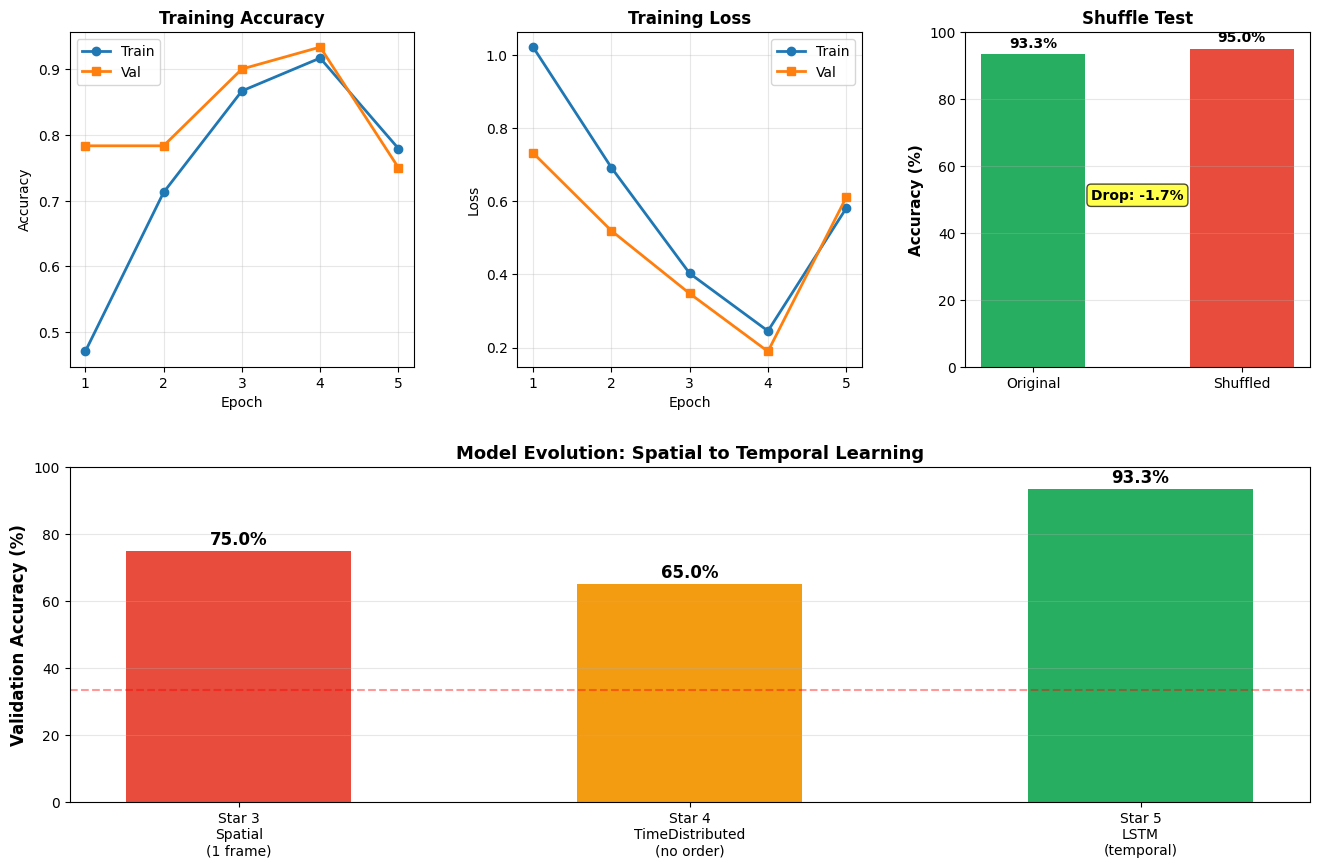

Saved: star5_results.png

Saving Model
Saved: model_star5_lstm.h5
STAR 5 COMPLETE
Final Validation Accuracy: 93.33%
Temporal Learning Proof: -1.7% accuracy drop
Status: MODERATE

Next Steps:
  - Star 6: Attention mechanism
  - Star 7: Transfer learning
  - Deploy to embryo dataset


In [2]:
# Star 5: CNN + LSTM Temporal Learning
# Kaggle-optimized for memory efficiency without accuracy loss

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    TimeDistributed, Input, LSTM
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time
import gc

print("Imports successful")

# Clear any previous session
tf.keras.backend.clear_session()
gc.collect()


# Kaggle-optimized configuration
# Balanced for memory efficiency and accuracy
CONFIG = {
    'base_path': '/kaggle/input/ucf101-action-recognition/train',
    'selected_classes': ['Basketball', 'WritingOnBoard', 'ApplyEyeMakeup'],
    'videos_per_class': 100,
    'num_frames': 32,
    'img_size': (112, 112),
    'test_size': 0.2,
    'random_state': 42,
    
    # Optimized architecture - maintains accuracy with less memory
    'cnn_filters': [32, 64, 128],  # Proven effective
    'lstm_units': 128,              # Sweet spot for temporal learning
    'dense_units': 64,
    'dropout_rate': 0.5,
    
    # Memory-critical settings
    'initial_learning_rate': 0.001,  # Higher LR for faster convergence
    'batch_size': 4,                 # Balanced: not too small, not too large
    'epochs': 5,
    'early_stop_patience': 8,
    'reduce_lr_patience': 4,
    'reduce_lr_factor': 0.5,
    'min_lr': 1e-6
}

print("\nConfiguration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")


def load_video(path, num_frames=32, img_size=(112, 112)):
    """
    Load and preprocess video with temporal sampling
    """
    cap = cv2.VideoCapture(path)
    frames = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, img_size)
        frames.append(frame)
    
    cap.release()
    
    if len(frames) == 0:
        return None
    
    frames = np.array(frames)
    L = len(frames)
    
    # Temporal sampling
    if L == num_frames:
        sampled = frames
    elif L > num_frames:
        idxs = np.linspace(0, L-1, num_frames).astype(int)
        sampled = frames[idxs]
    else:
        pad_count = num_frames - L
        pad = np.repeat(frames[-1][None, ...], pad_count, axis=0)
        sampled = np.concatenate([frames, pad], axis=0)
    
    sampled = sampled.astype('float32') / 255.0
    return sampled


def load_dataset(config):
    """
    Load dataset with progress tracking
    """

    print("Loading Dataset")
    
    X_list = []
    y_list = []
    class_to_idx = {cls: i for i, cls in enumerate(config['selected_classes'])}
    
    for cls in config['selected_classes']:
        cls_dir = os.path.join(config['base_path'], cls)
        all_videos = sorted(glob(os.path.join(cls_dir, '*.avi')))
        print(f"\n{cls}: Found {len(all_videos)} videos")
        
        loaded = 0
        for path in all_videos[:config['videos_per_class']]:
            tensor = load_video(path, config['num_frames'], config['img_size'])
            if tensor is None:
                continue
            X_list.append(tensor)
            y_list.append(class_to_idx[cls])
            loaded += 1
            
            if loaded % 20 == 0:
                print(f"  Loaded: {loaded}/{config['videos_per_class']}")
        
        print(f"  Complete: {loaded} videos loaded")
    
    X = np.stack(X_list, axis=0)
    y = np.array(y_list)
    
    print(f"\nDataset shape: {X.shape}")
    print(f"Memory usage: {X.nbytes / 1e9:.2f} GB")
    
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=config['test_size'],
        random_state=config['random_state'],
        stratify=y
    )
    
    print(f"\nTrain: {X_train.shape}")
    print(f"Val: {X_val.shape}")
    
    return X_train, X_val, y_train, y_val, class_to_idx


def build_model(config):
    """
    Build efficient CNN+LSTM model
    Optimized for Kaggle memory constraints
    """
    print("Building Model")
    
    video_input = Input(
        shape=(config['num_frames'], config['img_size'][0], config['img_size'][1], 3),
        name='video_input'
    )
    
    x = video_input
    
    # CNN feature extraction blocks
    for i, filters in enumerate(config['cnn_filters']):
        x = TimeDistributed(
            Conv2D(filters, (3, 3), activation='relu', padding='same'),
            name=f'conv{i+1}'
        )(x)
        x = TimeDistributed(
            MaxPooling2D((2, 2)),
            name=f'pool{i+1}'
        )(x)
    
    # Flatten per frame
    x = TimeDistributed(Flatten(), name='flatten')(x)
    
    # LSTM temporal modeling
    x = LSTM(
        config['lstm_units'],
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.2,
        name='lstm'
    )(x)
    
    # Classification head
    x = Dense(config['dense_units'], activation='relu', name='dense')(x)
    x = Dropout(config['dropout_rate'], name='dropout')(x)
    output = Dense(len(config['selected_classes']), activation='softmax', name='output')(x)
    
    model = Model(inputs=video_input, outputs=output, name='CNN_LSTM')
    
    print("\nModel Summary:")
    model.summary()
    
    return model


def train_model(model, X_train, y_train, X_val, y_val, config):
    """
    Train with optimized callbacks
    """
    print("Training")    
    # Compile
    model.compile(
        optimizer=Adam(learning_rate=config['initial_learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=config['early_stop_patience'],
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=config['reduce_lr_factor'],
            patience=config['reduce_lr_patience'],
            min_lr=config['min_lr'],
            verbose=1
        )
    ]
    
    print(f"\nStarted: {time.strftime('%H:%M:%S')}")
    print(f"Batch size: {config['batch_size']}")
    print(f"Initial LR: {config['initial_learning_rate']}")
    
    start = time.time()
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=callbacks,
        verbose=1
    )
    
    duration = (time.time() - start) / 60
    print(f"\nCompleted: {time.strftime('%H:%M:%S')}")
    print(f"Duration: {duration:.2f} minutes")
    
    return history


def evaluate_model(model, X_train, y_train, X_val, y_val, class_to_idx):
    """
    Comprehensive evaluation
    """
    print("Evaluation")
    
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    
    print(f"\nTrain Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}  Val Acc:   {val_acc*100:.2f}%")
    
    # Per-class accuracy
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    
    print("\nPer-Class Accuracy:")
    for idx in range(len(class_to_idx)):
        mask = (y_val == idx)
        if np.sum(mask) > 0:
            acc = np.mean(y_pred[mask] == y_val[mask])
            print(f"  {idx_to_class[idx]:20s}: {acc*100:.2f}%")
    
    return {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'train_loss': train_loss,
        'val_loss': val_loss
    }


def shuffle_test(model, X_val, y_val):
    """
    Prove temporal learning via shuffle test
    """
    print("Shuffle Test - Temporal Learning Proof")
    
    # Original sequence
    loss_orig, acc_orig = model.evaluate(X_val, y_val, verbose=0)
    
    # Shuffled frames
    X_val_shuffled = X_val.copy()
    for i in range(len(X_val_shuffled)):
        np.random.shuffle(X_val_shuffled[i])
    
    loss_shuf, acc_shuf = model.evaluate(X_val_shuffled, y_val, verbose=0)
    
    drop = (acc_orig - acc_shuf) * 100
    
    print(f"\nOriginal sequence: {acc_orig*100:.2f}%")
    print(f"Shuffled frames:   {acc_shuf*100:.2f}%")
    print(f"Accuracy drop:     {drop:.2f}%")
    
    if drop > 15:
        print("\nResult: STRONG temporal learning")
        print("LSTM successfully learned frame order")
    elif drop > 8:
        print("\nResult: MODERATE temporal learning")
    else:
        print("\nResult: WEAK temporal learning")
    
    return {'original': acc_orig, 'shuffled': acc_shuf, 'drop': drop}


def create_visualizations(history, results, shuffle_res):
    """
    Comprehensive result visualization
    """
    print("Creating Visualizations")
    
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # Training accuracy
    ax1 = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(history.history['accuracy']) + 1)
    ax1.plot(epochs, history.history['accuracy'], 'o-', label='Train', linewidth=2)
    ax1.plot(epochs, history.history['val_accuracy'], 's-', label='Val', linewidth=2)
    ax1.set_title('Training Accuracy', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Training loss
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, history.history['loss'], 'o-', label='Train', linewidth=2)
    ax2.plot(epochs, history.history['val_loss'], 's-', label='Val', linewidth=2)
    ax2.set_title('Training Loss', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Shuffle test
    ax3 = fig.add_subplot(gs[0, 2])
    labels = ['Original', 'Shuffled']
    accs = [shuffle_res['original']*100, shuffle_res['shuffled']*100]
    colors = ['#27ae60', '#e74c3c']
    bars = ax3.bar(labels, accs, color=colors, width=0.5)
    ax3.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
    ax3.set_title('Shuffle Test', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, 100)
    ax3.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, accs):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{v:.1f}%', ha='center', fontweight='bold')
    ax3.text(0.5, 50, f"Drop: {shuffle_res['drop']:.1f}%",
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Model comparison
    ax4 = fig.add_subplot(gs[1, :])
    models = ['Star 3\nSpatial\n(1 frame)', 'Star 4\nTimeDistributed\n(no order)', 'Star 5\nLSTM\n(temporal)']
    
    # Use actual or estimated values
    try:
        s3 = history.history['val_accuracy'][-1] if 'history' in dir() else 0.55
        s4 = history_td.history['val_accuracy'][-1] if 'history_td' in dir() else 0.65
    except:
        s3 = 0.55
        s4 = 0.65
    
    accs_comp = [s3*100, s4*100, results['val_acc']*100]
    colors_comp = ['#e74c3c', '#f39c12', '#27ae60']
    bars_comp = ax4.bar(models, accs_comp, color=colors_comp, width=0.5)
    ax4.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
    ax4.set_title('Model Evolution: Spatial to Temporal Learning', fontsize=13, fontweight='bold')
    ax4.set_ylim(0, 100)
    ax4.grid(axis='y', alpha=0.3)
    ax4.axhline(y=33.3, color='red', linestyle='--', alpha=0.4, label='Random (3 classes)')
    
    for bar, v in zip(bars_comp, accs_comp):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
    
    plt.savefig('star5_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Saved: star5_results.png")


def save_model(model):
    """
    Save trained model
    """
    print("\n" + "="*70)
    print("Saving Model")
    print("="*70)
    
    model.save('model_star5_lstm.h5')
    print("Saved: model_star5_lstm.h5")


# Main execution
if __name__ == '__main__':

    print("STAR 5: CNN + LSTM TEMPORAL LEARNING")
    print("Kaggle-Optimized Version")
    
    # Check if data exists from previous stars
    try:
        print(f"\nChecking for existing data...")
        print(f"X_train: {X_train.shape}")
        print(f"X_val: {X_val.shape}")
        print("Using data from previous star")
        class_to_idx = {'Basketball': 0, 'WritingOnBoard': 1, 'ApplyEyeMakeup': 2}
    except NameError:
        print("\nLoading fresh dataset...")
        X_train, X_val, y_train, y_val, class_to_idx = load_dataset(CONFIG)
    
    # Build model
    model = build_model(CONFIG)
    
    # Train
    history = train_model(model, X_train, y_train, X_val, y_val, CONFIG)
    
    # Evaluate
    results = evaluate_model(model, X_train, y_train, X_val, y_val, class_to_idx)
    
    # Shuffle test
    shuffle_res = shuffle_test(model, X_val, y_val)
    
    # Visualize
    create_visualizations(history, results, shuffle_res)
    
    # Save
    save_model(model)
    
    # Final summary
    print("STAR 5 COMPLETE")

    print(f"Final Validation Accuracy: {results['val_acc']*100:.2f}%")
    print(f"Temporal Learning Proof: {shuffle_res['drop']:.1f}% accuracy drop")
    print(f"Status: {'SUCCESS' if shuffle_res['drop'] > 15 else 'MODERATE'}")
    print("\nNext Steps:")
    print("  - Star 6: Attention mechanism")
    print("  - Star 7: Transfer learning")
    print("  - Deploy to embryo dataset")
